# Trajectories

1. Imports, setup parameters and load the DataStructure.
2. Select trial rows and slice outbound/inbound body positions.
3. Define the single-trial, multi-trial and path-complexity plotting functions.
4. Read the matching video's first frame and return each figure.

The loading and training-protocol filtering follow `spatial_fixed.ipynb`.
Positions remain in video pixels and times remain in recording seconds.


In [15]:
##### Imports #########################################################
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import movement.plots
import movement.kinematics
import numpy as np
import pandas as pd
from IPython.display import display

from data_conduit.datastructures import slice_stream, slice_stream_per_trial
from data_conduit.integrations.DLC.pose import pose_to_movement
from data_conduit.refactor_qc import TRAINING_FIRST_MID_LAST_DETAIL, training_spec, filter_trials
from movement_figures.data_template.loading import build_datastructure
from movement_figures.misc import visual_streams_check, configure_simplified_trial_df
from movement_figures.video import read_session_video_frame

# Show every trial-table column when inspecting the loaded data.
pd.set_option("display.max_columns", None)


In [16]:
##### Setup Parameters ################################################


# === 1| Select Mice, Days and Recording Folders Before Reading Files =============

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")

LEVEL_SELECTORS = {
    'l0_selector': 'MR_M01569515', 
    'l1_selector': 'Day21'
    }                                                                               # Example choices belong here: l0_selector and l1_selector.

# INCLUDE_SESSIONS = ('2026-06-21T093349Z',)                                          # Optional list of recording folder names; None keeps selected folders.
# STREAMS = ('trials', 'events', 'video', 'dlc')                                      # These figures require events/trials and aligned pose; other sources remain available.


#=== 2| Set the trial filtering parameters for the experiment protocol ============
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)                                  # Flattens `{training_detail}` table into per-session spec. 

# included_sessions = training_session_names(spec)                                      # Returns a list of session folder names that match the spec.
#   Not used here, as sessions have been filtered in another way. If other sessions 
#   not in the above spec are used, then applying the `filter_trials` function with 
#   the above spec could result in incorrect filtering. 



In [17]:
##### Load DataStructure ###############################################################


#=== Load data ========================================================================
fig_ds = build_datastructure(
    root = ROOT,                                                                        # Directory above the named hierarchy levels.
    level_names = ("mouseID", "day"),                                                   # Lab layout: root / mouseID / day / session.
    streams = ("trials", "session_settings", "video", "dlc"),
    include = None,                                                                     # Keep these session folder names; None keeps all.
    exclude = None,                                                                     # Alternatively omit these session folder names.
    raw_events = True,                                                                  # Convenience alias for adding "events" to the requested sources.
    device_yaml = "./device.yml",                                                       # Lab Nosepoke board register definitions.
    soundcard_yaml = "./soundcard.yml",                                                 # Lab SoundCard register definitions.
    nosepoke_count = 18,                                                                # Port count used by the existing Q_C parser.
    trial_start_buffer = 0.0,                                                           # Preserve the existing lab parser setting.
    trial_spec = None,                                                                  # Optional experiment rules; None keeps the existing Q_C specification. 
    #    Not used here, as sessions are already selected. 
    #    If session is not one in the spec, then subsequent use of 
    #   `filter_trials` to apply correct experiment protocol rules could be incorrect.

    dlc_file_format = "auto",                                                           # Existing reader prefers CSV, otherwise HDF5.
    **LEVEL_SELECTORS,
)


#=== Select and load the streams of interest from datastructure. ======================
fig_ds.select()
streams = fig_ds.load()



#=== Create convenient compact trial dataframe without some unnecessary columns. ======
#       More useful for visual inspection and analysis. 
#       Check the misc.py file for the default columns to keep and drop. 

streams['compact_trials'] = configure_simplified_trial_df(              
    trial_df = streams['trials'],
    modify_in_place = False,                                            # Whether to modify the trial dataframe in place or return a new dataframe. 
)


#=== Apply Trial Filtering Protocol to construct new stream objects ===================
streams['filtered_trials'] = filter_trials(
    trials = streams['trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

streams['filtered_compact_trials'] = filter_trials(
    trials = streams['compact_trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

#=== Merge Pose & Confidence Streams ==================================================
streams['dlc:movement'] = pose_to_movement(
    slice_stream(streams["dlc:position"], #selectors={"session": session_id}
    ),
    slice_stream(streams["dlc:confidence"], #selectors={"session": session_id}
    ),
)
# display(streams['dlc:movement'])


#=== Visual streams check =============================================================
visual_streams_check(
    loaded_ds_object = streams,
    show_stream_shapes = True,
    show_stream_dtypes = True,
    display_streams = False
)

     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80
     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80


=========================
### Summary of Loaded Streams
=========================

,Stream Name,Shape,Type
0,session_settings:metadata,"(1, 23)",DataFrame
1,session_settings:trials,"(303, 132)",DataFrame
2,video,"(36354, 5)",DataFrame
3,dlc:position,"(36354, 5, 2)",DataArray
4,dlc:confidence,"(36354, 5)",DataArray
5,events,"(1487, 5)",DataFrame
6,trials,"(106, 28)",DataFrame
7,compact_trials,"(106, 19)",DataFrame
8,filtered_trials,"(80, 30)",DataFrame
9,filtered_compact_trials,"(80, 21)",DataFrame


In [18]:
##### Select Trials and Slice Positions ################################

# === 1 | Keep the same first eight protocol-filtered rows as spatial_fixed ===
selected_trials = slice_stream(streams['filtered_trials'][:6])

# Choose the body point and named animal explicitly, before plotting.
point = streams['dlc:movement']["position"].sel(
    keypoint="body", individual="individual_0", drop=True,
)

# === 2 | Use the trial table's outbound and inbound phase boundaries ========
# Each list has one position array per selected trial, in the same row order.
outbound = slice_stream_per_trial(
    stream=point, trials=selected_trials, segment="outbound", time_coord="time",
)
inbound = slice_stream_per_trial(
    stream=point, trials=selected_trials, segment="inbound", time_coord="time",
)

# === 3 | Choose the single-trial example from those selected rows ===========
single_trial_row = 0  # Zero-based row within selected_trials; change this here.
outbound_trial = outbound[single_trial_row]
inbound_trial = inbound[single_trial_row]
trial_index = selected_trials.iloc[single_trial_row]["trial_index"]

display(selected_trials)


,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,TTT,TTP,outbound_start_time,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day,training_day,day_trial_index
0,24,5922.650944,5930.218816,False,True,332,345,5928.000992,5925.144000,0,0,Success,OFF,0.0,300.0,5.350048,2.217824,5922.650944,5928.000992,False,True,5928.000992,5930.218816,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,1
1,25,5930.218816,5937.076640,False,True,346,359,5935.200000,5932.724000,0,0,Success,OFF,0.0,300.0,4.981184,1.876640,5930.218816,5935.200000,False,True,5935.200000,5937.076640,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,2
2,26,5937.076640,5947.709248,False,True,360,373,5944.049984,5939.589984,0,0,Success,OFF,0.0,300.0,6.973344,3.659264,5937.076640,5944.049984,False,True,5944.049984,5947.709248,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,3
3,27,5947.709248,5956.329760,False,True,374,387,5953.200000,5950.220992,0,0,Success,OFF,0.0,300.0,5.490752,3.129760,5947.709248,5953.200000,False,True,5953.200000,5956.329760,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,4
4,28,5956.329760,5963.959072,False,True,388,401,5962.250976,5958.838976,0,0,Success,OFF,0.0,300.0,5.921216,1.708096,5956.329760,5962.250976,False,True,5962.250976,5963.959072,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,5
5,29,5963.959072,5980.614496,False,True,402,415,5975.602976,5970.956992,-1,0,Miss,OFF,NaN,150.0,11.643904,5.011520,5963.959072,5975.602976,False,True,5975.602976,5980.614496,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,6


## Figure functions

The two spatial figures use the selected recording's first video frame and the
same pixel coordinates as the body positions. `movement.plots.plot_centroid_trajectory`
draws the supplied body point; no additional centroid is calculated because the
keypoint and individual were already selected above. Points preserve missing
observations without joining across gaps.

The complexity figure retains the established comparison: **outbound path length**
versus **mean inbound path deviation**. Length is a provisional complexity measure,
not a straightness score. Deviation is the perpendicular distance to the infinite
line through the observed inbound endpoints, not distance from the home port.


In [19]:
# background_frame

In [20]:
##### Single-Trial Trajectory ##########################################

def plot_single_trial_trajectory(
    outbound_trial, 
    inbound_trial, 
    background_frame, 
    trial_index,
):
    """Plot one trial's outbound and inbound body positions using movement.

    Parameters
    ----------
    outbound_trial, inbound_trial : xarray.DataArray
        Position arrays already sliced to the two phases of the same trial.
        Each has dimensions (time, space), x/y coordinates in video pixels,
        and the recording clock in seconds. The body keypoint and individual
        must be selected beforehand. No confidence masking, smoothing or
        interpolation is applied here; missing positions remain missing.
    background_frame : numpy.ndarray
        First RGB frame of the same recording, shaped (height, width, 3).
        Full-frame pixel limits are used in both panels, with y increasing
        downwards. Integer position coordinates align with pixel centres.
    trial_index : int
        Original trial number shown in the title. This labels the supplied
        paths; it does not choose or slice a trial inside this function.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Outbound and inbound panels over the first frame. Each panel has
        movement's time colour bar, in recording seconds for that phase.
    axes : numpy.ndarray
        One-dimensional array containing outbound and inbound axes, in order.
        Each observed body position is a point; no connecting line is drawn.
    """
    # === 1 | Match the panel coordinates to the video pixels ================
    height, width = background_frame.shape[:2]
    extent = (-0.5, width - 0.5, height - 0.5, -0.5)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")

    # === 2 | Draw each phase over the same first frame =======================
    for ax, path, phase in zip(
        axes, (outbound_trial, inbound_trial), ("Outbound", "Inbound"),
    ):
        ax.imshow(background_frame, origin="upper", extent=extent, alpha=0.55)
        movement.plots.plot_centroid_trajectory(
            da=path, ax=ax, s=4, alpha=0.70,
        )  # movement colours these observed samples by their recording time.
        ax.collections[-1].colorbar.set_label("Recording time (s)")
        ax.set(
            title=phase, xlabel="x (px)", ylabel="y (px)",
            xlim=extent[:2], ylim=extent[2:], aspect="equal",
        )

    # === 3 | Keep the original trial number visible ==========================
    fig.suptitle(f"Body trajectory: trial {trial_index}")
    return fig, axes


In [21]:
##### Multi-Trial Trajectories ##########################################

def plot_multi_trial_trajectories(
    outbound, inbound, selected_trials, background_frame,
):
    """Group the selected body trajectories by outcome and trial phase.

    Parameters
    ----------
    outbound, inbound : list[xarray.DataArray]
        One (time, space) position array per selected trial, in exactly the
        row order of selected_trials. Values are x/y pixels for the already
        selected body keypoint and individual. Phase boundaries are supplied
        by the earlier slicing cells. Missing positions are not filled.
    selected_trials : pandas.DataFrame
        Matching rows from one recording, containing trial_index and outcome.
        The original trial numbers set colours; outcome sets the panel row.
        Every supplied trial is drawn in its outcome row, without additional
        filtering. Rows appear in the order outcomes first occur in the table.
    background_frame : numpy.ndarray
        First RGB frame of that same recording, shaped (height, width, 3).
        Every panel covers the full frame in pixels, with y increasing downwards.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Outcome rows and outbound/inbound columns, each over the first frame.
        One shared colour bar identifies original trial numbers. The same
        trial has the same colour in both phase columns.
    axes : numpy.ndarray
        Two-dimensional axes array with shape (number of outcomes, 2).
        Points show the observed samples without connecting across gaps.
    """
    # === 1 | Set one colour per original trial and one row per outcome =======
    outcomes = selected_trials["outcome"].unique()
    norm = Normalize(
        selected_trials["trial_index"].min(), selected_trials["trial_index"].max(),
    )
    cmap = plt.get_cmap("viridis")
    fig, axes = plt.subplots(
        len(outcomes), 2, figsize=(12, 4.5 * len(outcomes)),
        squeeze=False, layout="constrained",
    )
    height, width = background_frame.shape[:2]
    extent = (-0.5, width - 0.5, height - 0.5, -0.5)

    # === 2 | Draw each outcome's paths over the matching video frame =========
    for row, outcome in enumerate(outcomes):
        for column, (phase, paths) in enumerate(zip(
            ("Outbound", "Inbound"), (outbound, inbound),
        )):
            ax = axes[row, column]
            ax.imshow(background_frame, origin="upper", extent=extent, alpha=0.55)
            for path, trial_index, trial_outcome in zip(
                paths, selected_trials["trial_index"], selected_trials["outcome"],
            ):
                if trial_outcome == outcome:  # Place each trial in its outcome row.
                    movement.plots.plot_centroid_trajectory(
                        da=path, ax=ax, c=[cmap(norm(trial_index))], s=4, alpha=0.70,
                    )
            ax.set(
                title=f"{outcome}: {phase}", xlabel="x (px)", ylabel="y (px)",
                xlim=extent[:2], ylim=extent[2:], aspect="equal",
            )

    # === 3 | Label the colour scale shared by all phase panels ===============
    colourbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes.ravel().tolist(),
    )
    colourbar.set_ticks(selected_trials["trial_index"])
    colourbar.set_label("Original trial index")
    fig.suptitle("Selected body trajectories")
    return fig, axes


In [22]:
##### Path Complexity: Outbound Length and Inbound Deviation ############

def plot_path_complexity(outbound, inbound, selected_trials):
    """Measure and compare outbound length with mean inbound path deviation.

    movement sums distances between successive outbound positions to obtain
    length. For inbound positions it calculates each sample's perpendicular
    distance from the infinite line through the observed first and last
    positions. The plotted deviation is the arithmetic sample mean.

    Parameters
    ----------
    outbound, inbound : list[xarray.DataArray]
        One (time, space) x/y body-position array per selected trial, in the
        same row order as selected_trials. Coordinates are video pixels.
        A measured phase needs at least two samples and finite coordinates
        throughout. Inbound endpoints must also differ to define their line.
        Other measurements stay NaN. These existing eligibility rules avoid
        movement's default filling of missing positions. No confidence
        threshold, interpolation or smoothing is introduced here.
    selected_trials : pandas.DataFrame
        Matching trial rows from one recording, with session, trial_index and
        outcome columns. Original trial identities are kept in the returned
        metrics. Outcomes set scatter groups, using Matplotlib's colour cycle.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Outbound path length (x) versus mean inbound deviation (y), both in
        pixels. Each visible dot pairs measurements from the same trial.
        Length is a provisional complexity measure, not a straightness score.
    ax : matplotlib.axes.Axes
        Comparison axes, labelled in pixels. These are metric axes rather
        than video x/y coordinates, so no video image is placed behind them.
    metrics : pandas.DataFrame
        Copy of session, trial_index and outcome with outbound_path_length
        and inbound_mean_deviation columns, both in pixels. All supplied
        trials remain in the table; a NaN coordinate has no visible scatter
        point. Inbound samples have equal weight, without time weighting.
        Outbound length depends on sampling rate and tracking jitter.
    """
    # === 1 | Keep trial identities and leave unavailable measurements as NaN =
    metrics = selected_trials[["session", "trial_index", "outcome"]].copy()
    metrics["outbound_path_length"] = np.nan
    metrics["inbound_mean_deviation"] = np.nan

    # === 2 | Measure only complete paths, without filling tracking gaps =====
    for row_index, outbound_trial, inbound_trial in zip(metrics.index, outbound, inbound):
        # --- Outbound length: sum the distances between consecutive samples.
        if outbound_trial.sizes["time"] >= 2 and bool(np.isfinite(outbound_trial).all()):
            metrics.loc[row_index, "outbound_path_length"] = float(
                movement.kinematics.compute_path_length(outbound_trial)
            )

        # --- Inbound deviation: mean distance from the observed endpoint line.
        if inbound_trial.sizes["time"] >= 2 and bool(np.isfinite(inbound_trial).all()):
            if bool((inbound_trial.isel(time=0) != inbound_trial.isel(time=-1)).any()):
                metrics.loc[row_index, "inbound_mean_deviation"] = float(
                    movement.kinematics.compute_path_deviation(inbound_trial).mean(
                        "time", skipna=False,
                    )
                )

    # === 3 | Pair each trial's two measurements in the comparison ============
    fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
    for outcome, rows in metrics.groupby("outcome", sort=False):
        ax.scatter(
            rows["outbound_path_length"], rows["inbound_mean_deviation"],
            label=outcome, s=38, alpha=0.8,
        )  # Matplotlib leaves points with a missing coordinate undrawn.
    ax.set(
        xlabel="Outbound path length (px)", ylabel="Mean inbound deviation (px)",
        title="Outbound length versus inbound deviation",
        xlim=(0, None), ylim=(0, None),
    )
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend(title="Outcome")
    return fig, ax, metrics


## Create the figures

The calls below reuse the selected trial rows and phase slices above. The single
example uses `single_trial_row`; the multi-trial and complexity figures use every
row of `selected_trials`. All data must describe one recording, whose first frame
is read below. To choose different trials, change the selection cell and rerun it.

Path measurements retain the existing complete-position rule. A trial with a
missing measurement remains in `metrics` as NaN and has no comparison dot; its
observed trajectory points remain visible in the spatial figures.


In [23]:
##### Video Background #################################################

# Read the first frame for the single recording represented by selected_trials.
session_id = selected_trials["session"].unique().item()
background_frame, video_path = read_session_video_frame(fig_ds.sessions[session_id].path)

display(background_frame)

array([[[13, 13, 13],
        [13, 13, 13],
        [13, 13, 13],
        ...,
        [22, 22, 22],
        [22, 22, 22],
        [22, 22, 22]],

       [[13, 13, 13],
        [13, 13, 13],
        [13, 13, 13],
        ...,
        [22, 22, 22],
        [22, 22, 22],
        [22, 22, 22]],

       [[13, 13, 13],
        [13, 13, 13],
        [13, 13, 13],
        ...,
        [22, 22, 22],
        [22, 22, 22],
        [22, 22, 22]],

       ...,

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]]], shape=(1260, 1620, 3), dtype=uint8)

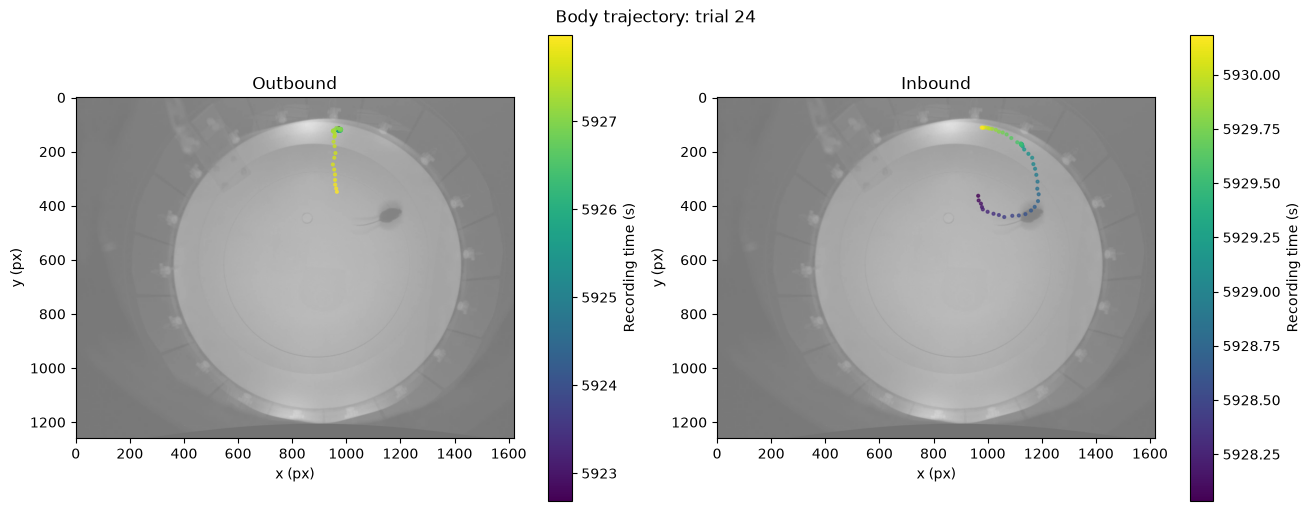

In [24]:
##### Return the Single-Trial Trajectory ################################

single_trial_figure, single_trial_axes = plot_single_trial_trajectory(
    outbound_trial=outbound_trial,
    inbound_trial=inbound_trial,
    background_frame=background_frame,
    trial_index=trial_index,
)
single_trial_figure.savefig("single_trial_trajectory.png")
plt.close(single_trial_figure)  # The final line displays the returned figure once.
single_trial_figure


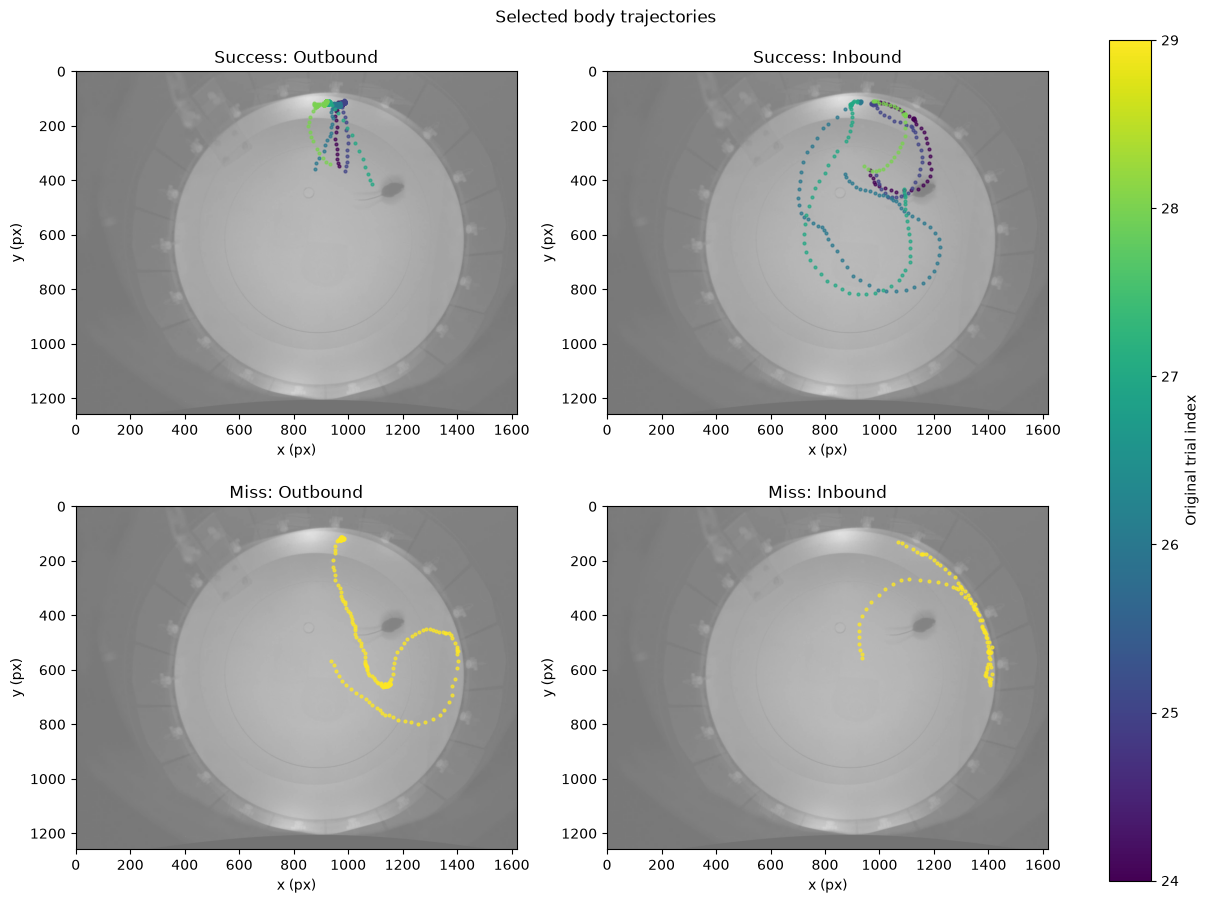

In [25]:
##### Return the Multi-Trial Trajectories ###############################

multi_trial_figure, multi_trial_axes = plot_multi_trial_trajectories(
    outbound=outbound,
    inbound=inbound,
    selected_trials=selected_trials,
    background_frame=background_frame,
)
multi_trial_figure.savefig("multi_trial_trajectories.png")
plt.close(multi_trial_figure)
multi_trial_figure


outcome
Success    60
Miss       20
Name: count, dtype: int64


,session,trial_index,outcome,outbound_path_length,inbound_mean_deviation
0,2026-06-21T093349Z,24,Success,365.989084,111.937691
1,2026-06-21T093349Z,25,Success,358.880088,81.063209
2,2026-06-21T093349Z,26,Success,421.477833,150.799114
3,2026-06-21T093349Z,27,Success,483.859936,160.718256
4,2026-06-21T093349Z,28,Success,454.784680,78.390377
...,...,...,...,...,...
75,2026-06-21T093349Z,102,Success,2365.077579,222.376442
76,2026-06-21T093349Z,103,Miss,6706.001948,263.115696
77,2026-06-21T093349Z,104,Miss,3667.338151,87.797544
78,2026-06-21T093349Z,105,Success,11986.089112,143.893528


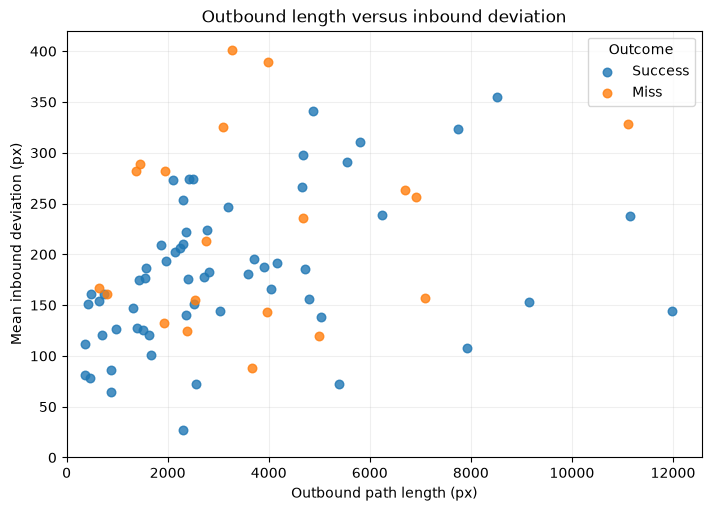

In [27]:
##### Return the Path-Complexity Figure #################################


# === 1 | Keep the same first eight protocol-filtered rows as spatial_fixed ===
selected_trials = slice_stream(streams['filtered_trials'])
print(selected_trials['outcome'].value_counts())
# Choose the body point and named animal explicitly, before plotting.
point = streams['dlc:movement']["position"].sel(
    keypoint="body", individual="individual_0", drop=True,
)

# === 2 | Use the trial table's outbound and inbound phase boundaries ========
# Each list has one position array per selected trial, in the same row order.
outbound = slice_stream_per_trial(
    stream=point, trials=selected_trials, segment="outbound", time_coord="time",
)
inbound = slice_stream_per_trial(
    stream=point, trials=selected_trials, segment="inbound", time_coord="time",
)

complexity_figure, complexity_axes, metrics = plot_path_complexity(
    outbound=outbound,
    inbound=inbound,
    selected_trials=selected_trials,
)
display(metrics)
complexity_figure.savefig("path_complexity_figure.png")
plt.close(complexity_figure)
complexity_figure
